# Preprocessing Data / Feature Engineering:
## Loading Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
df = pd.read_csv('financial_regression.csv')
df.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [3]:
df.shape

(3904, 47)

In [4]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  us_rates_%          176 non-null    float64
 14  CPI                 176 non-null    float64
 15  usd_chf             3694 non-null   float64
 16  eur_us

In [5]:
print(df.columns)

Index(['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close',
       'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high',
       'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low',
       'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open',
       'silver high', 'silver low', 'silver close', 'silver volume',
       'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close',
       'oil volume', 'oil high-low', 'platinum open', 'platinum high',
       'platinum low', 'platinum close', 'platinum volume',
       'platinum high-low', 'palladium open', 'palladium high',
       'palladium low', 'palladium close', 'palladium volume',
       'palladium high-low', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume'],
      dtype='object')


In [6]:
print("Percentage of Missing Values (Before Feature Engineering) :")
(df.isnull().sum()/len(df))*100

Percentage of Missing Values (Before Feature Engineering) :


date                   0.000000
sp500 open             4.738730
sp500 high             4.738730
sp500 low              4.738730
sp500 close            4.738730
sp500 volume           4.738730
sp500 high-low         4.738730
nasdaq open            4.738730
nasdaq high            4.738730
nasdaq low             4.738730
nasdaq close           4.738730
nasdaq volume          4.738730
nasdaq high-low        4.738730
us_rates_%            95.491803
CPI                   95.491803
usd_chf                5.379098
eur_usd                5.379098
GDP                   98.539959
silver open            4.738730
silver high            4.738730
silver low             4.738730
silver close           4.738730
silver volume          4.738730
silver high-low        4.738730
oil open               4.738730
oil high               4.738730
oil low                4.738730
oil close              4.738730
oil volume             4.738730
oil high-low           4.738730
platinum open          4.738730
platinum

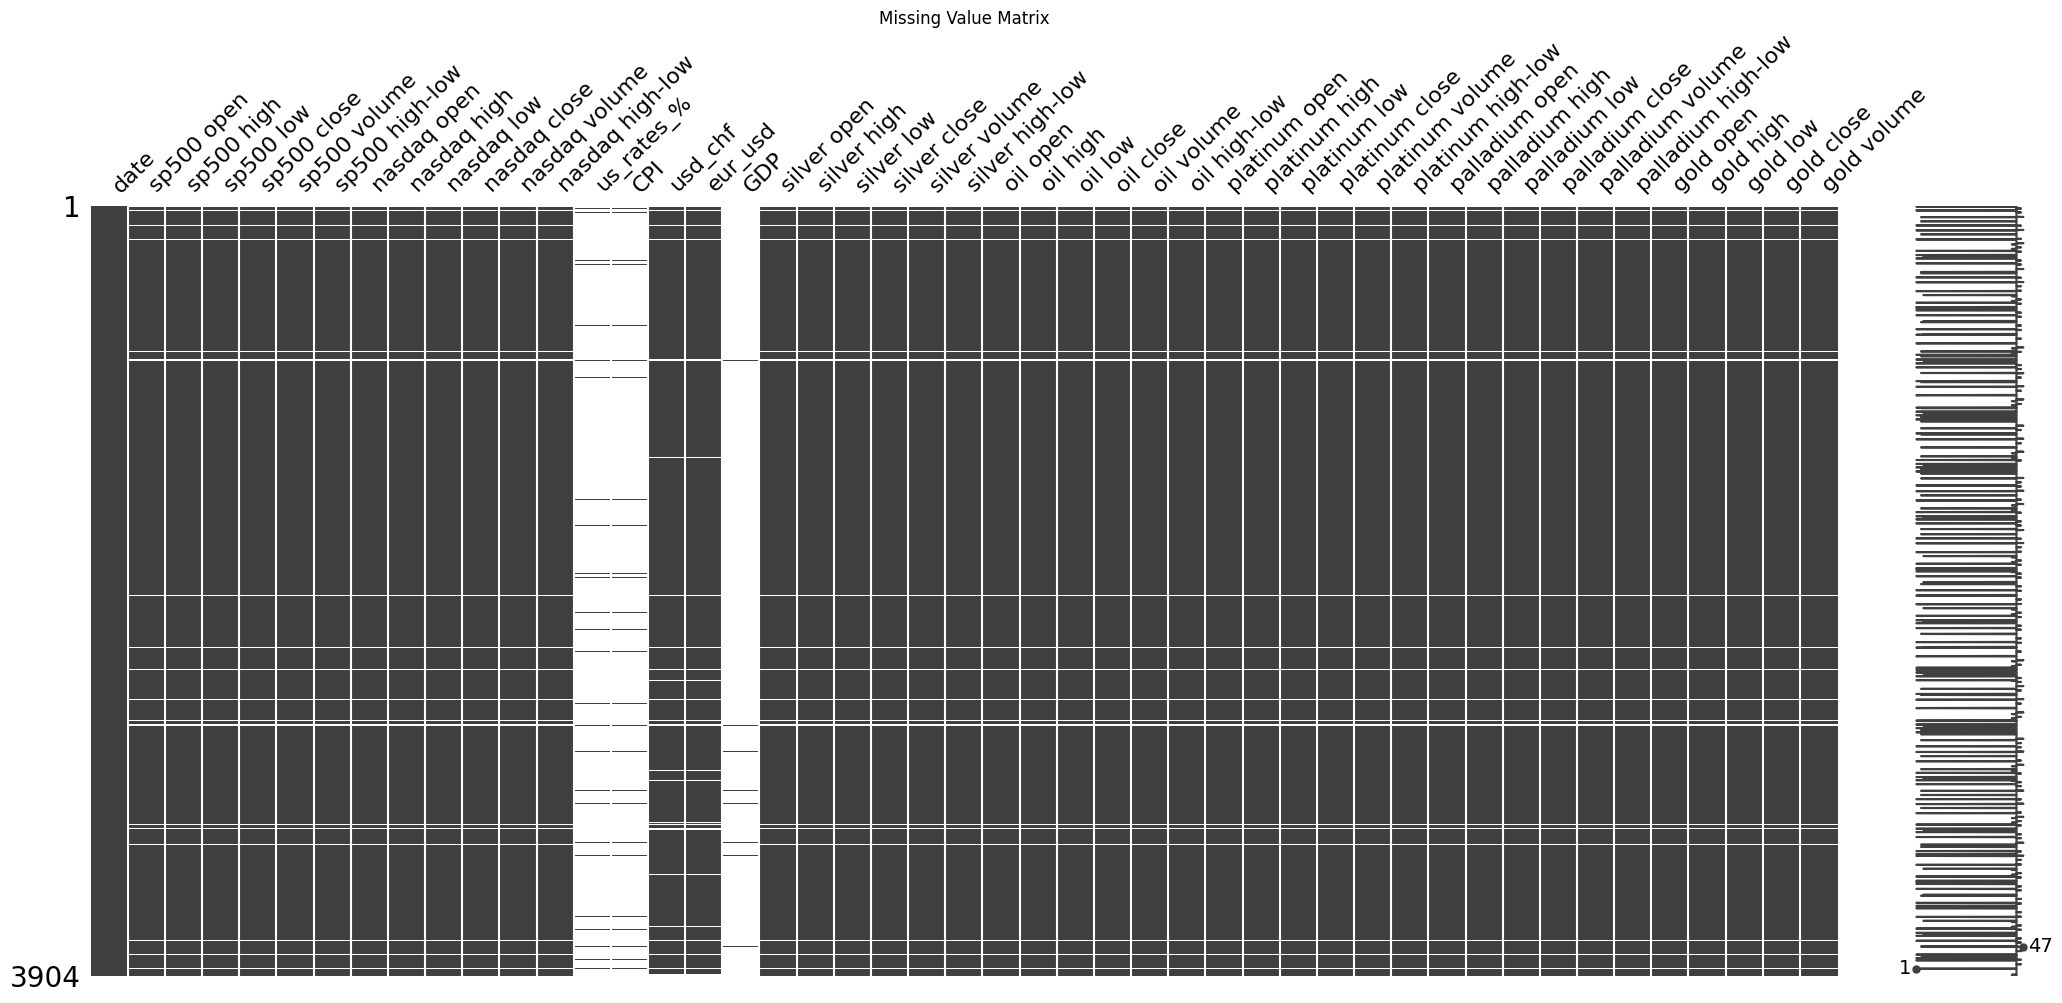

In [7]:
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

In [8]:
# We must standardize the dates in our data in order for our model to understand that markets close on Friday and re-open on Monday.

# Convert to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract calendar components
df["DayOfWeek"] = df["date"].dt.dayofweek  # 0 = Monday, 4 = Friday
df["Month"] = df["date"].dt.month
df["Quarter"] = df["date"].dt.quarter
df["DayOfYear"] = df["date"].dt.dayofyear
df["IsMonthEnd"] = df["date"].dt.is_month_end.astype(int)

In [9]:
# In regards to our linear regression model, we want to predict the future price of gold. In this data set we are split up by the 
# days of the week the stock market is open so we must take this into consideration when we split the model. Here we append the future closing
# price of gold for a given observation as it must serve as our target variable. We also compute the daily return from the difference of the 
# gold open and gold closing price. 

# Create the target: shifted by -1 day (Tomorrow's Close)
df["Target_Next_Close"] = df["gold close"].shift(-1)

# Create lagged features (Yesterday's values)
df["Close_Lag1"] = df["gold close"].shift(1)
df["Open_Lag1"] = df["gold open"].shift(1)

# Daily Return feature (Today's Open to Close spread)
df["Daily_Return"] = (df["gold close"] - df["gold open"]) / df["gold open"]

df[["gold open","gold close","Target_Next_Close","Close_Lag1","Open_Lag1","Daily_Return"]]

,gold open,gold close,Target_Next_Close,Close_Lag1,Open_Lag1,Daily_Return
0,111.51,112.03,110.86,NaN,NaN,0.004663
1,111.35,110.86,NaN,112.03,111.51,-0.004401
2,NaN,NaN,111.52,110.86,111.35,NaN
3,110.95,111.52,108.94,NaN,NaN,0.005137
4,109.97,108.94,107.37,111.52,110.95,-0.009366
...,...,...,...,...,...,...
3899,247.75,248.63,251.27,247.15,247.62,0.003552
3900,250.00,251.27,251.22,248.63,247.75,0.005080
3901,252.74,251.22,253.93,251.27,250.00,-0.006014
3902,253.06,253.93,250.87,251.22,252.74,0.003438


In [10]:
df.shape

(3904, 56)

In [11]:
print("Percentage of Missing Values (After Feature Engineering) :")
(df.isnull().sum()/len(df))*100

Percentage of Missing Values (After Feature Engineering) :


date                   0.000000
sp500 open             4.738730
sp500 high             4.738730
sp500 low              4.738730
sp500 close            4.738730
sp500 volume           4.738730
sp500 high-low         4.738730
nasdaq open            4.738730
nasdaq high            4.738730
nasdaq low             4.738730
nasdaq close           4.738730
nasdaq volume          4.738730
nasdaq high-low        4.738730
us_rates_%            95.491803
CPI                   95.491803
usd_chf                5.379098
eur_usd                5.379098
GDP                   98.539959
silver open            4.738730
silver high            4.738730
silver low             4.738730
silver close           4.738730
silver volume          4.738730
silver high-low        4.738730
oil open               4.738730
oil high               4.738730
oil low                4.738730
oil close              4.738730
oil volume             4.738730
oil high-low           4.738730
platinum open          4.738730
platinum

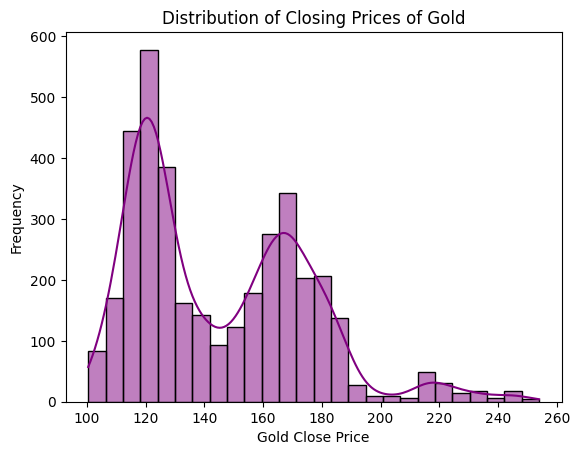

In [12]:
sns.histplot(df["Target_Next_Close"],color = 'purple',kde = True)
plt.title("Distribution of Closing Prices of Gold")
plt.xlabel("Gold Close Price")
plt.ylabel("Frequency")
plt.show()

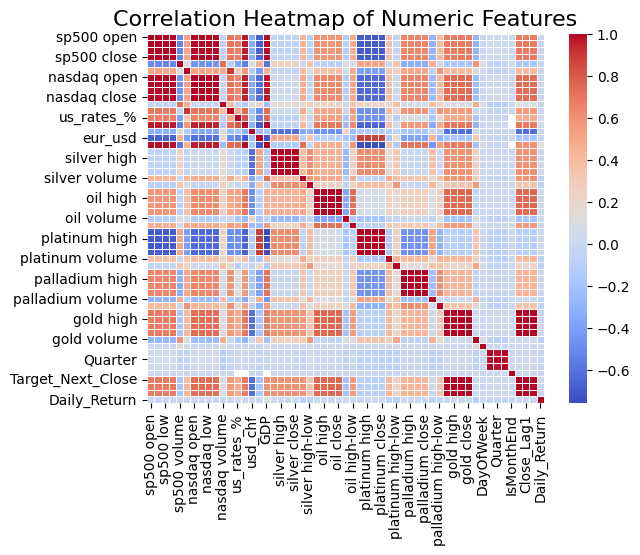

In [13]:
df_numeric = df.select_dtypes(include=[np.number])

sns.heatmap(df_numeric.corr(), cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()

## Modeling part


In [14]:
df["Target_Next_Close"] = df["gold close"].shift(-1)
df["Close_Lag1"] = df["gold close"].shift(1)

In [15]:
# MODELING: Predicting Next-Day Gold Closing Price

import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [16]:
# Prepare the modeling data
# Preserve chronological order rather than randomly mixing future observations into the training data.
# Make sure observations are in chronological order
df = df.sort_values("date").reset_index(drop=True)

# Remove rows where the target is unavailable
model_df = df.dropna(subset=["Target_Next_Close"]).copy()

print("Modeling dataset shape:", model_df.shape)

Modeling dataset shape: (3718, 56)


In [17]:
# Select the predictors
features = [
    "sp500 open",
    "sp500 high",
    "sp500 low",
    "sp500 close",
    "sp500 volume",
    "sp500 high-low",

    "nasdaq open",
    "nasdaq high",
    "nasdaq low",
    "nasdaq close",
    "nasdaq volume",
    "nasdaq high-low",

    "silver open",
    "silver high",
    "silver low",
    "silver close",
    "silver volume",
    "silver high-low",

    "oil open",
    "oil high",
    "oil low",
    "oil close",
    "oil volume",
    "oil high-low",

    "platinum open",
    "platinum high",
    "platinum low",
    "platinum close",
    "platinum volume",
    "platinum high-low",

    "palladium open",
    "palladium high",
    "palladium low",
    "palladium close",
    "palladium volume",
    "palladium high-low",

    "gold open",
    "gold high",
    "gold low",
    "gold close",
    "gold volume",

    "DayOfWeek",
    "Month",
    "Quarter",
    "DayOfYear",
    "IsMonthEnd",
    "Daily_Return"
]

X = model_df[features]
y = model_df["Target_Next_Close"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3718, 47)
y shape: (3718,)


In [18]:
# Train/Test Split
split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining period:")
print(model_df["date"].iloc[:split_index].min())
print("to")
print(model_df["date"].iloc[:split_index].max())

print("\nTesting period:")
print(model_df["date"].iloc[split_index:].min())
print("to")
print(model_df["date"].iloc[-1])

Training observations: 2974
Testing observations: 744

Training period:
2010-01-14 00:00:00
to
2021-11-04 00:00:00

Testing period:
2021-11-05 00:00:00
to
2024-10-22 00:00:00


In [19]:
# Handle Missing Values Inside the Pipeline
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [20]:
# Build the Linear Regression Model
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [21]:
# Make Predictions
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

In [23]:
# Evaluate the Model
# We'll use: MAE, RMSE, R²
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Training": [train_mae, train_rmse, train_r2],
    "Testing": [test_mae, test_rmse, test_r2]
})

results

,Metric,Training,Testing
0,MAE,1.817994,3.660744
1,RMSE,4.959635,11.410681
2,R²,0.948042,0.742097


In [24]:
# Compare Actual vs Predicted
comparison = pd.DataFrame({
    "Date": model_df["date"].iloc[split_index:],
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

comparison.head(10)

,Date,Actual,Predicted
3121,2021-11-05,170.45,170.036445
3122,2021-11-08,171.29,170.217140
3123,2021-11-09,173.15,171.280209
3124,2021-11-10,174.12,173.440307
3125,2021-11-11,174.45,174.186773
3126,2021-11-12,174.18,173.872327
3127,2021-11-15,172.92,173.864373
3128,2021-11-16,174.50,172.327299
3129,2021-11-17,173.94,174.944576
3130,2021-11-18,172.61,173.648257


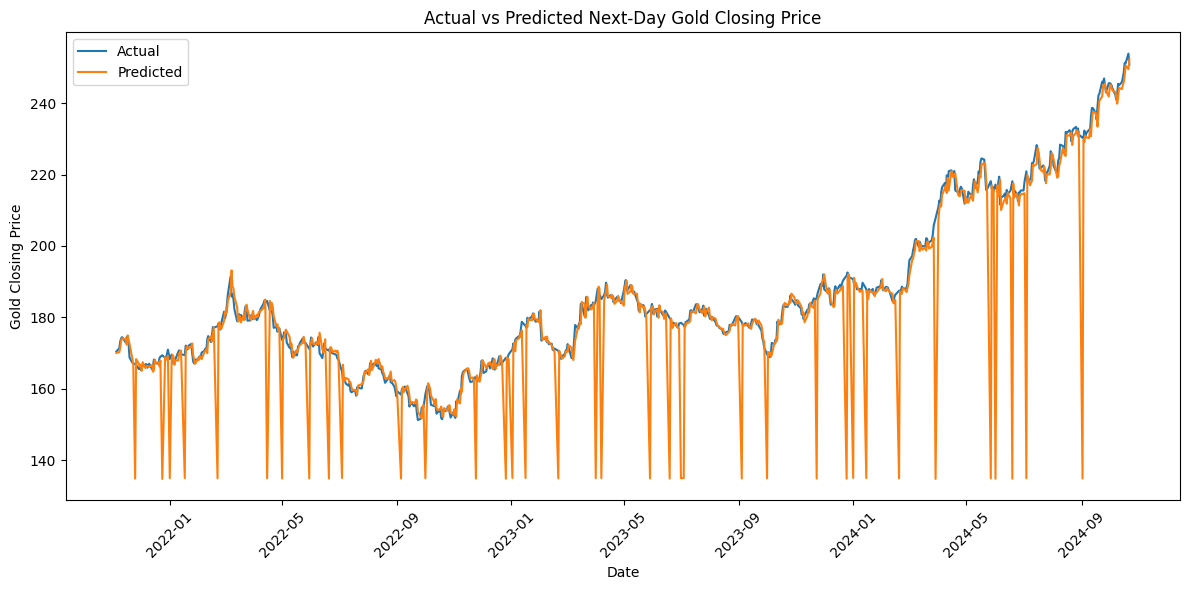

In [25]:
# Plot Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    comparison["Date"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Date"],
    comparison["Predicted"],
    label="Predicted"
)

plt.title("Actual vs Predicted Next-Day Gold Closing Price")
plt.xlabel("Date")
plt.ylabel("Gold Closing Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

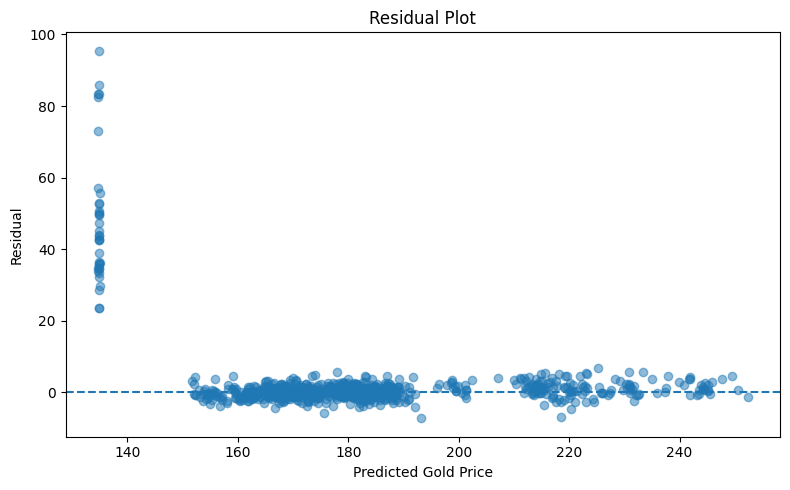

In [26]:
# Residual Analysis
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_test_pred, residuals, alpha=0.5)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Gold Price")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

In [27]:
# Ridge Regression
ridge_model = Pipeline([
    ("preprocessor", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("----------------")
print("MAE :", ridge_mae)
print("RMSE:", ridge_rmse)
print("R²  :", ridge_r2)

Ridge Regression
----------------
MAE : 7.003322627677995
RMSE: 13.51520215230029
R²  : 0.6381915187315399


In [29]:
# Comparison
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression"
    ],
    "MAE": [
        test_mae,
        ridge_mae
    ],
    "RMSE": [
        test_rmse,
        ridge_rmse
    ],
    "R²": [
        test_r2,
        ridge_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R²
0,Linear Regression,3.660744,11.410681,0.742097
1,Ridge Regression,7.003323,13.515202,0.638192
